# YOLOv8n Training for Search-and-Rescue

This notebook trains a YOLOv8n model on the search-and-rescue dataset, evaluates its performance, benchmarks inference speed, and exports the model to ONNX format.

In [ ]:
!pip install ultralytics

In [1]:
import os
import time
import torch
from ultralytics import YOLO
from pathlib import Path
import yaml

In [2]:
# --- Configuration ---

# Paths
DATASET_DIR = Path("/kaggle/input/datasets/nikolasgegenava/sard-search-and-rescue/search-and-rescue")
PROJECT_NAME = "/kaggle/working/runs/sar_yolov8"
WORKING_DIR = Path("/kaggle/working")
RUN_NAME = "yolov8n_training"

# Training Hyperparameters
EPOCHS = 100
BATCH_SIZE = 50
IMG_SIZE = 640
DEVICE = 0 if torch.cuda.is_available() else 'cpu'

# Export options
EXPORT_FORMAT = "onnx"

print(f"Using device: {DEVICE}")

Using device: 0


## 1. Prepare Dataset Configuration

We need to ensure `data.yaml` has the correct paths.

In [6]:
original_yaml = DATASET_DIR / "data.yaml"
train_yaml = WORKING_DIR / "data_train.yaml"

with open(original_yaml, 'r') as f:
    data_config = yaml.safe_load(f)

# Set absolute path for the dataset
data_config['path'] = str(DATASET_DIR.absolute())

data_config['train'] = "train/images"
data_config['val'] = "valid/images"
data_config['test'] = "test/images"

with open(train_yaml, 'w') as f:
    yaml.dump(data_config, f)

print(f"Created training config at: {train_yaml}")

Created training config at: /kaggle/working/data_train.yaml


## 2. Train YOLOv8n Model

In [7]:
# Load a pretrained YOLOv8n model
model = YOLO("yolov8n.pt")

# Train the model
results = model.train(
    data=str(train_yaml),
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    imgsz=IMG_SIZE,
    device=DEVICE,
    project=PROJECT_NAME,
    name=RUN_NAME
)

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=50, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_train.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_training, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

## 3. Evaluation and Metrics

In [8]:
# Load the best model
best_model_path = Path(PROJECT_NAME) / RUN_NAME / "weights" / "best.pt"
model = YOLO(best_model_path)

# Validate the model
metrics = model.val()

print("\n--- Performance Metrics ---")
print(f"Precision: {metrics.results_dict['metrics/precision(B)']:.4f}")
print(f"Recall:    {metrics.results_dict['metrics/recall(B)']:.4f}")
print(f"mAP50:     {metrics.results_dict['metrics/mAP50(B)']:.4f}")
print(f"mAP50-95:  {metrics.results_dict['metrics/mAP50-95(B)']:.4f}")

# F1 Score
f1_score = metrics.box.f1.mean()
print(f"F1-Score:  {f1_score:.4f}")

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.5 ms, read: 237.6±42.3 MB/s, size: 125.0 KB)
val: Scanning /kaggle/input/datasets/nikolasgegenava/sard-search-and-rescue/search-and-rescue/valid/labels... 1144 images, 177 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1144/1144 682.0it/s 1.7s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/nikolasgegenava/sard-search-and-rescue/search-and-rescue/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 72/72 7.5it/s 9.6s0.1s
                   all       1144       1463      0.962      0.904      0.943      0.641
Speed: 1.1ms preprocess, 3.7ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

--- Performance Metrics ---
Precision: 0.9622
Recall

## 4. Size and Inference Speed

In [9]:
# Model size
file_size = best_model_path.stat().st_size / (1024 * 1024)
print(f"Model Size (PyTorch): {file_size:.2f} MB")

# Inference Speed
speed = metrics.speed
total_time_ms = sum(speed.values())
fps = 1000 / total_time_ms

print("\n--- Inference Speed (on Validation Set) ---")
print(f"Pre-process:  {speed['preprocess']:.2f} ms")
print(f"Inference:    {speed['inference']:.2f} ms")
print(f"Post-process: {speed['postprocess']:.2f} ms")
print(f"Total:        {total_time_ms:.2f} ms per image")
print(f"FPS:          {fps:.2f}")

Model Size (PyTorch): 5.97 MB

--- Inference Speed (on Validation Set) ---
Pre-process:  1.13 ms
Inference:    3.67 ms
Post-process: 0.80 ms
Total:        5.60 ms per image
FPS:          178.46


## 5. Export to ONNX

In [10]:
print(f"Exporting to {EXPORT_FORMAT}...")
exported_path = model.export(format=EXPORT_FORMAT)
exported_file = Path(exported_path)

exported_size = exported_file.stat().st_size / (1024 * 1024)
print(f"Model exported to: {exported_path}")
print(f"Exported Model Size: {exported_size:.2f} MB")

Exporting to onnx...
Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs/sar_yolov8/yolov8n_training/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 281ms
Prepared 2 packages in 4.32s
Installed 2 packages in 9ms
 + onnxruntime-gpu==1.25.0
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 5.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 6.6s, saved as '/kaggle/working/runs/sar_yolov8

## 6. Visualizing Sample Predictions

Let's visualize the model's predictions on some random images from the test set.

Loaded best model from ../weights/yolov8n/best.pt for visualization.

0: 640x640 5 humans, 9.5ms
1: 640x640 (no detections), 9.5ms
2: 640x640 1 human, 9.5ms
3: 640x640 1 human, 9.5ms
4: 640x640 (no detections), 9.5ms
5: 640x640 1 human, 9.5ms
Speed: 2.4ms preprocess, 9.5ms inference, 3.1ms postprocess per image at shape (1, 3, 640, 640)


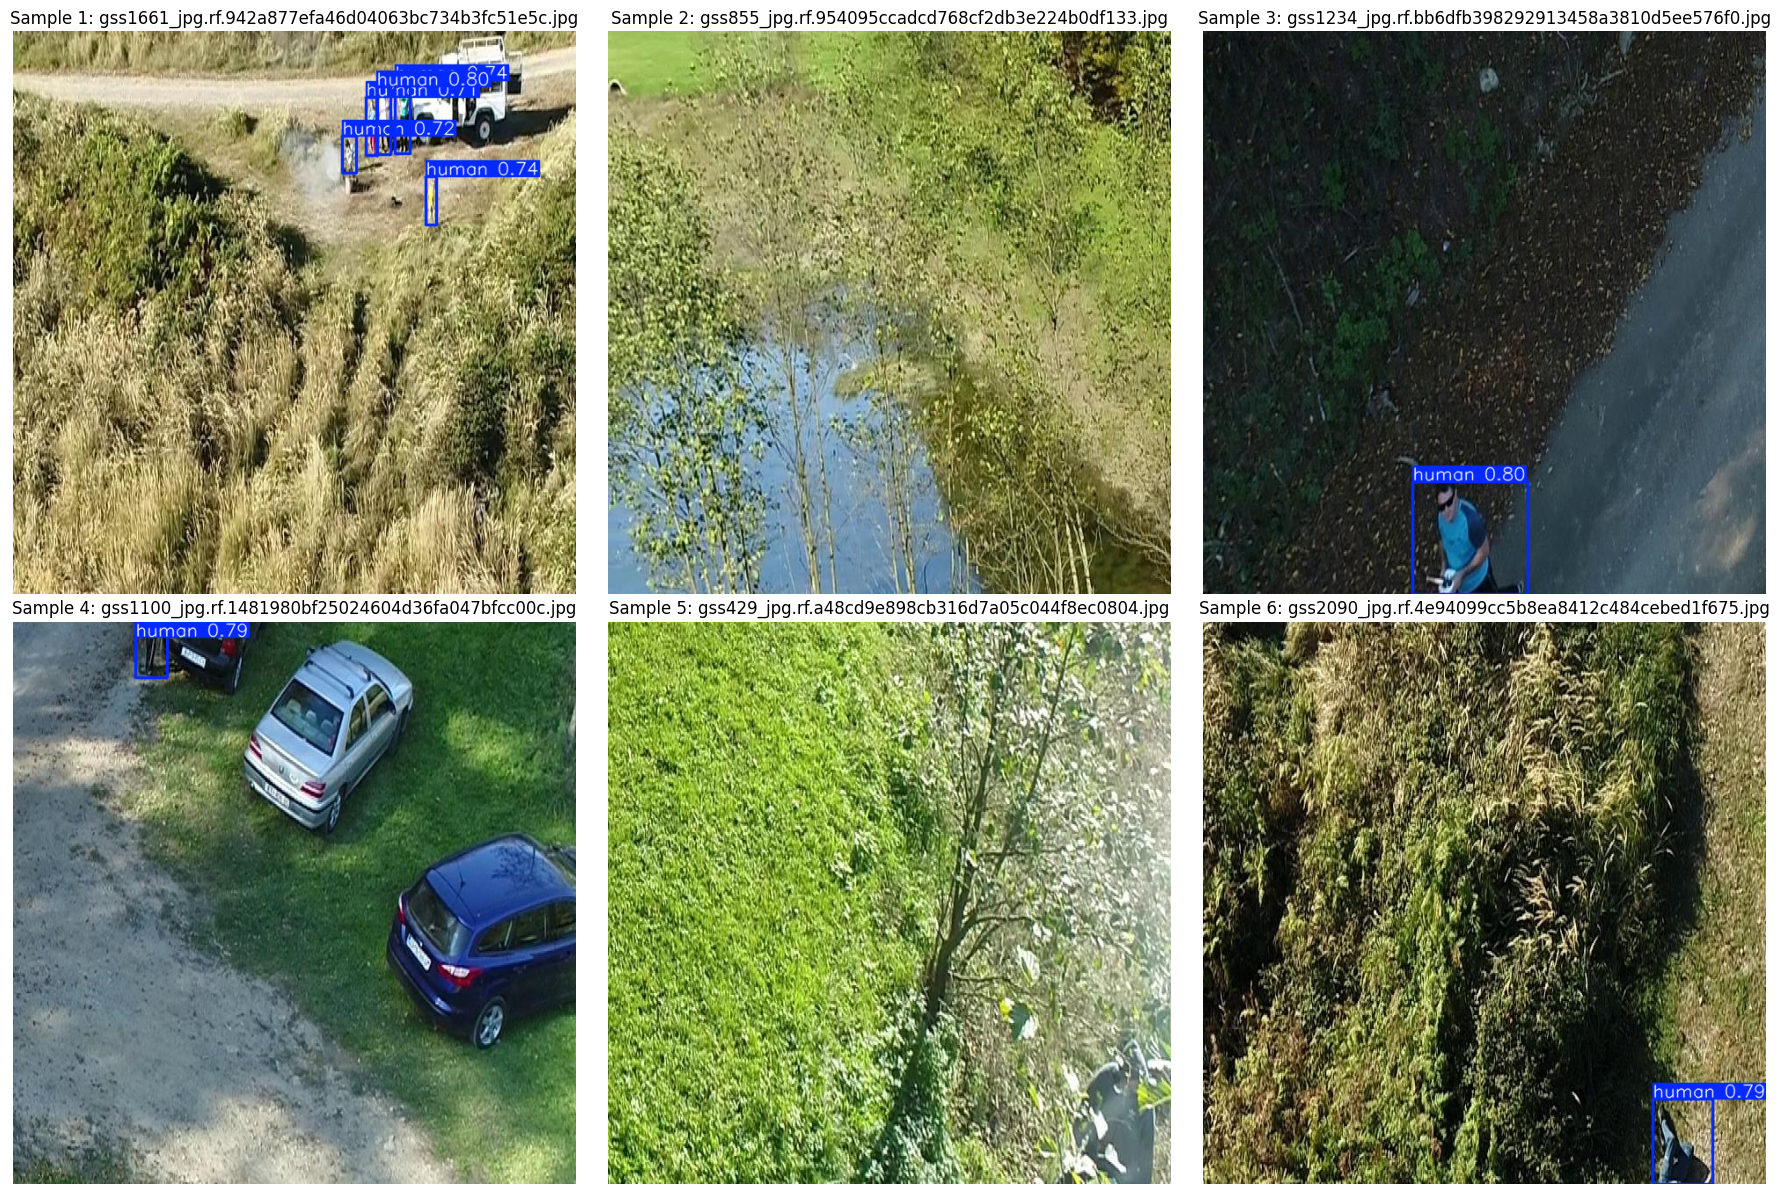

In [3]:
import random
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path
from ultralytics import YOLO

# Ensure the best model is loaded
best_model_path = Path("../weights/yolov8n/best.pt")
if best_model_path.exists():
    model = YOLO(best_model_path)
    print(f"Loaded best model from {best_model_path} for visualization.")
else:
    print(f"Warning: Best model not found at {best_model_path}. Using current model.")

# Get all test images
test_images_path = Path("../data/search-and-rescue") / "test" / "images"
test_images = list(test_images_path.glob("*.jpg")) + list(test_images_path.glob("*.png")) + list(test_images_path.glob("*.jpeg"))

if not test_images:
    print(f"No images found in {test_images_path}. Please check DATASET_DIR.")
else:
    # Randomly select 6 images
    num_samples = min(6, len(test_images))
    sample_images = random.sample(test_images, num_samples)

    # Run inference
    results = model.predict(source=sample_images, imgsz=IMG_SIZE, conf=0.25)

    # Plot results
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for i, result in enumerate(results):
        # Plot the result (returns a BGR numpy array)
        res_plotted = result.plot()
        # Convert BGR to RGB for matplotlib
        res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)
        
        axes[i].imshow(res_rgb)
        axes[i].set_title(f"Sample {i+1}: {sample_images[i].name}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

## 7. ROpti Metric Calculation

ROpti is defined as: $ROpti = \frac{TP - FP}{TP + FN}$

Given:
- $Recall (R) = \frac{TP}{TP + FN}$
- $Precision (P) = \frac{TP}{TP + FP} \implies TP + FP = \frac{TP}{P} \implies FP = TP(\frac{1}{P} - 1)$

Substituting into the ROpti formula:
$ROpti = \frac{TP - TP(\frac{1}{P} - 1)}{TP + FN} = \frac{TP(2 - \frac{1}{P})}{TP + FN} = R(2 - \frac{1}{P})$

In [4]:
import os
from ultralytics import YOLO
from pathlib import Path

# --- Local Configuration ---
# Assuming we are in the project root or the notebook handles the path
LOCAL_DATA_YAML = "data/search-and-rescue/data_train.yaml"
LOCAL_MODEL_PATH = "weights/yolov8n/best.pt"

if os.path.exists(LOCAL_MODEL_PATH):
    # Load the best model
    model = YOLO(LOCAL_MODEL_PATH)
    
    # Validate the model using local data config
    # This will calculate metrics for the current local environment
    print(f"Running validation on {LOCAL_DATA_YAML}...")
    metrics = model.val(data=LOCAL_DATA_YAML)

    # Extract Precision and Recall
    precision = metrics.results_dict['metrics/precision(B)']
    recall = metrics.results_dict['metrics/recall(B)']

    # Calculate ROpti: R * (2 - 1/P)
    ropti = recall * (2 - 1 / precision) if precision > 0 else 0

    print("\n--- ROpti Metric (calculated from Model Validation) ---")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"ROpti:     {ropti:.4f}")
else:
    print(f"Error: Model file not found at {LOCAL_MODEL_PATH}")

Ultralytics 8.4.21 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 2050, 3771MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


FileNotFoundError: '/kaggle/working/data_train.yaml' does not exist